
# GVH Diagonal Cubic 0.2.24 — Anisotropic Star and Exact Source Projector
## Reconstruction robuste : TOV anisotrope, source exacte, champ intérieur et raccordement analytique

**Auteur : Charlemagne O Laurince**

---

## Objectif

Cette version reconstruit entièrement le notebook 0.2.24 selon une architecture numérique séparée :

1. résoudre uniquement l’étoile anisotrope ;
2. obtenir
   \[
   R_\star,\quad M(r),\quad p_r(r),\quad p_t(r);
   \]
3. construire
   \[
   J_D(r)=\sqrt{\frac23}[p_r(r)-p_t(r)];
   \]
4. résoudre séparément l’équation intérieure de \(d(r)\) ;
5. utiliser la solution extérieure exacte ;
6. raccorder \(d\) et \(d'\) à \(R_\star\) ;
7. calculer analytiquement la charge extérieure \(Q_D\).

Cette architecture évite :

- l’intégration TOV et directionnelle simultanée ;
- le tir global fragile ;
- les régions extérieures vides ;
- les valeurs `NaN` systématiques de \(Q_D\) ;
- l’erreur `np.polyfit: expected non-empty vector`.

---

## Résultat théorique central

Le projecteur spatial sans trace est :

\[
\Pi_{\mu\nu}[T]
=
h_\mu{}^\alpha h_\nu{}^\beta T_{\alpha\beta}
-
\frac13h_{\mu\nu}
h^{\alpha\beta}T_{\alpha\beta}.
\]

Pour :

\[
T_{\hat\mu\hat\nu}
=
\operatorname{diag}(\rho,p_r,p_t,p_t),
\]

la source du mode sphérique est :

\[
\boxed{
J_D(r)
=
\sqrt{\frac23}[p_r(r)-p_t(r)]
}.
\]


In [1]:

import sympy as sp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp
from scipy.interpolate import PchipInterpolator

sp.init_printing()
np.set_printoptions(precision=12, suppress=True)

print("Environnement chargé.")


Environnement chargé.



# 1. Projecteur spatial exact


In [2]:

r, theta = sp.symbols(
    "r theta",
    positive=True,
    real=True
)

Phi = sp.Function("Phi")(r)
Lambda = sp.Function("Lambda")(r)

g_cov = sp.diag(
    -sp.exp(2*Phi),
    sp.exp(2*Lambda),
    r**2,
    r**2*sp.sin(theta)**2
)

g_inv = sp.simplify(g_cov.inv())

u_contra = sp.Matrix([
    sp.exp(-Phi),
    0,
    0,
    0
])

u_cov = sp.simplify(
    g_cov*u_contra
)

h_cov = sp.simplify(
    g_cov+u_cov*u_cov.T
)

h_mixed = sp.simplify(
    h_cov*g_inv
)

normalization = sp.simplify(
    (u_contra.T*g_cov*u_contra)[0]
)

orthogonality = sp.simplify(
    h_cov*u_contra
)

idempotence = sp.simplify(
    h_mixed*h_mixed-h_mixed
)

trace_h = sp.simplify(
    sp.trace(h_mixed)
)

display(normalization)
display(orthogonality)
display(idempotence)
display(trace_h)


-1

⎡0⎤
⎢ ⎥
⎢0⎥
⎢ ⎥
⎢0⎥
⎢ ⎥
⎣0⎦

⎡0  0  0  0⎤
⎢          ⎥
⎢0  0  0  0⎥
⎢          ⎥
⎢0  0  0  0⎥
⎢          ⎥
⎣0  0  0  0⎦

3


# 2. Fluide anisotrope et projection sans trace


In [3]:

rho, p_r, p_t = sp.symbols(
    "rho p_r p_t",
    real=True
)

s_contra = sp.Matrix([
    0,
    sp.exp(-Lambda),
    0,
    0
])

s_cov = sp.simplify(
    g_cov*s_contra
)

T_cov = sp.simplify(
    (rho+p_t)*u_cov*u_cov.T
    + p_t*g_cov
    + (p_r-p_t)*s_cov*s_cov.T
)

h_contra = sp.simplify(
    g_inv*h_cov*g_inv
)

spatial_T = sp.simplify(
    h_mixed*T_cov*h_mixed.T
)

spatial_trace_T = sp.simplify(
    sum(
        h_contra[mu,nu]*T_cov[mu,nu]
        for mu in range(4)
        for nu in range(4)
    )
)

Pi_cov = sp.simplify(
    spatial_T
    - sp.Rational(1,3)
    * h_cov
    * spatial_trace_T
)

Pi_trace = sp.simplify(
    sum(
        h_contra[mu,nu]*Pi_cov[mu,nu]
        for mu in range(4)
        for nu in range(4)
    )
)

Pi_spatial = sp.simplify(
    Pi_cov*u_contra
)

Pi_isotropic = sp.simplify(
    Pi_cov.subs(p_r,p_t)
)

display(Pi_cov)
display(Pi_trace)
display(Pi_spatial)
display(Pi_isotropic)


⎡0           0                 0                  0          ⎤
⎢                                                            ⎥
⎢                2⋅Λ(r)                                      ⎥
⎢   2⋅(pᵣ - pₜ)⋅ℯ                                            ⎥
⎢0  ───────────────────        0                  0          ⎥
⎢            3                                               ⎥
⎢                                                            ⎥
⎢                         2                                  ⎥
⎢                        r ⋅(-pᵣ + pₜ)                       ⎥
⎢0           0           ─────────────            0          ⎥
⎢                              3                             ⎥
⎢                                                            ⎥
⎢                                        2               2   ⎥
⎢                                       r ⋅(-pᵣ + pₜ)⋅sin (θ)⎥
⎢0           0                 0        ─────────────────────⎥
⎣                                                 3    

0

⎡0⎤
⎢ ⎥
⎢0⎥
⎢ ⎥
⎢0⎥
⎢ ⎥
⎣0⎦

⎡0  0  0  0⎤
⎢          ⎥
⎢0  0  0  0⎥
⎢          ⎥
⎢0  0  0  0⎥
⎢          ⎥
⎣0  0  0  0⎦


# 3. Source scalaire sphérique

Dans la base orthonormée :

\[
E_D
=
\frac1{\sqrt6}
\operatorname{diag}(2,-1,-1).
\]

La projection donne :

\[
J_D
=
\sqrt{\frac23}(p_r-p_t).
\]


In [4]:

Delta = sp.symbols(
    "Delta",
    real=True
)

Pi_orth = sp.diag(
    sp.Rational(2,3)*Delta,
    -sp.Rational(1,3)*Delta,
    -sp.Rational(1,3)*Delta
)

E_D = sp.diag(
    2,-1,-1
)/sp.sqrt(6)

J_D_symbolic = sp.simplify(
    sum(
        E_D[i,j]*Pi_orth[i,j]
        for i in range(3)
        for j in range(3)
    )
)

display(E_D)
display(J_D_symbolic)


⎡√6            ⎤
⎢──   0     0  ⎥
⎢3             ⎥
⎢              ⎥
⎢    -√6       ⎥
⎢0   ────   0  ⎥
⎢     6        ⎥
⎢              ⎥
⎢          -√6 ⎥
⎢0    0    ────⎥
⎣           6  ⎦

√6⋅Δ
────
 3  


# 4. Équation d’état et anisotropie

Nous utilisons le polytrope :

\[
p_r=K\rho^\Gamma,
\]

et l’anisotropie régulière :

\[
\Delta_a(r)
=
p_t-p_r
=
\lambda_a
r^2(\rho+p_r)
\frac{m+4\pi r^3p_r}{r^3+\varepsilon}.
\]

Au centre :

\[
\Delta_a(0)=0.
\]


In [5]:

def rho_from_pressure(
    pressure,
    K_poly=0.12,
    Gamma_poly=2.0
):
    pressure = float(pressure)

    if pressure <= 0:
        return 0.0

    return (
        pressure/K_poly
    )**(
        1.0/Gamma_poly
    )


def anisotropy_value(
    radius,
    mass,
    pressure,
    density,
    lambda_a,
    epsilon=1e-12
):
    if pressure <= 0:
        return 0.0

    return (
        lambda_a
        * radius**2
        * (density+pressure)
        * (
            mass
            + 4*np.pi*radius**3*pressure
        )
        / (
            radius**3+epsilon
        )
    )



# 5. Étape 1 — Résolution indépendante de l’étoile

Les équations TOV anisotropes sont :

\[
m'=4\pi r^2\rho,
\]

\[
\Phi'
=
\frac{m+4\pi r^3p_r}{r(r-2m)},
\]

\[
p_r'
=
-(\rho+p_r)\Phi'
+
\frac{2(p_t-p_r)}r.
\]

L’intégration s’arrête à :

\[
p_r(R_\star)=0.
\]


In [6]:

def solve_anisotropic_star(
    p_center=0.02,
    K_poly=0.12,
    Gamma_poly=2.0,
    lambda_a=0.02,
    rmax=30.0,
    n_eval=2500
):
    r0 = 1e-6

    rho_c = rho_from_pressure(
        p_center,
        K_poly,
        Gamma_poly
    )

    m0 = (
        4*np.pi
        * rho_c
        * r0**3/3
    )

    y0 = [
        m0,
        0.0,
        p_center
    ]

    def rhs(radius,state):
        mass,Phi_value,pressure = state

        if pressure <= 0:
            return [0.0,0.0,0.0]

        density = rho_from_pressure(
            pressure,
            K_poly,
            Gamma_poly
        )

        Delta_value = anisotropy_value(
            radius,
            mass,
            pressure,
            density,
            lambda_a
        )

        denominator = (
            radius*(radius-2*mass)
        )

        if denominator <= 0:
            raise RuntimeError(
                "Compacité pathologique r <= 2m."
            )

        gravity = (
            mass
            + 4*np.pi
            * radius**3
            * pressure
        )/denominator

        dm = (
            4*np.pi
            * radius**2
            * density
        )

        dPhi = gravity

        dp = (
            -(density+pressure)
            * gravity
            + 2*Delta_value/radius
        )

        return [
            dm,
            dPhi,
            dp
        ]

    def surface_event(radius,state):
        return state[2]

    surface_event.terminal = True
    surface_event.direction = -1

    radii = np.linspace(
        r0,
        rmax,
        n_eval
    )

    solution = solve_ivp(
        rhs,
        (r0,rmax),
        y0,
        t_eval=radii,
        events=surface_event,
        method="DOP853",
        rtol=1e-10,
        atol=1e-12,
        max_step=0.03
    )

    if not solution.success:
        raise RuntimeError(
            solution.message
        )

    if solution.t_events[0].size == 0:
        raise RuntimeError(
            "La surface p_r=0 n’a pas été trouvée."
        )

    R_star = float(
        solution.t_events[0][0]
    )

    M_star = float(
        solution.y_events[0][0][0]
    )

    return solution,R_star,M_star



# 6. Profils stellaires

La solution TOV fournit directement :

\[
R_\star,\quad M(r),\quad p_r(r).
\]

Nous reconstruisons ensuite :

\[
\rho(r),\quad
p_t(r)=p_r(r)+\Delta_a(r).
\]


In [7]:

STAR_PARAMETERS = {
    "p_center":0.02,
    "K_poly":0.12,
    "Gamma_poly":2.0,
    "lambda_a":0.02
}

star_solution,R_star,M_star = solve_anisotropic_star(
    **STAR_PARAMETERS
)

r_star_grid = star_solution.t
m_star_grid = star_solution.y[0]
Phi_star_grid = star_solution.y[1]
p_r_grid = np.maximum(
    star_solution.y[2],
    0.0
)

rho_grid = np.array([
    rho_from_pressure(
        p,
        STAR_PARAMETERS["K_poly"],
        STAR_PARAMETERS["Gamma_poly"]
    )
    for p in p_r_grid
])

Delta_grid = np.array([
    anisotropy_value(
        radius,
        mass,
        pressure,
        density,
        STAR_PARAMETERS["lambda_a"]
    )
    for radius,mass,pressure,density
    in zip(
        r_star_grid,
        m_star_grid,
        p_r_grid,
        rho_grid
    )
])

p_t_grid = p_r_grid+Delta_grid

print("R_star =",R_star)
print("M_star =",M_star)
print("2M/R =",2*M_star/R_star)


R_star = 0.39757708692319865
M_star = 0.03263681983443744
2M/R = 0.16417857521423013


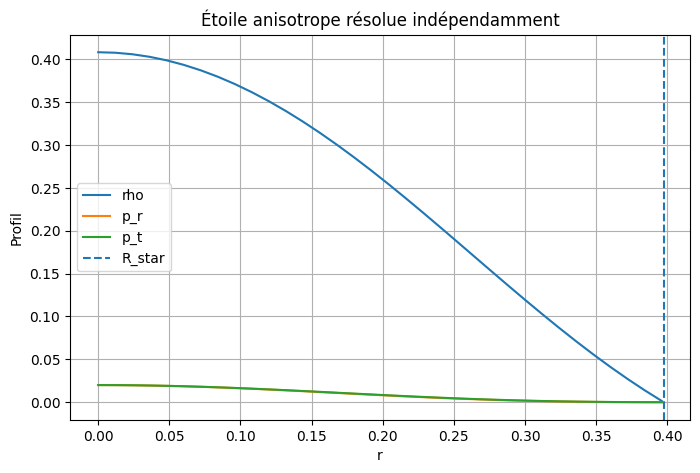

In [8]:

plt.figure(figsize=(8,5))
plt.plot(r_star_grid,rho_grid,label="rho")
plt.plot(r_star_grid,p_r_grid,label="p_r")
plt.plot(r_star_grid,p_t_grid,label="p_t")
plt.axvline(R_star,linestyle="--",label="R_star")
plt.xlabel("r")
plt.ylabel("Profil")
plt.title("Étoile anisotrope résolue indépendamment")
plt.grid(True)
plt.legend()
plt.show()



# 7. Étape 2 — Construction de la source exacte

Sur la solution stellaire :

\[
J_D(r)
=
\sqrt{\frac23}
[p_r(r)-p_t(r)]
=
-\sqrt{\frac23}\Delta_a(r).
\]

À l’extérieur :

\[
J_D(r)=0.
\]


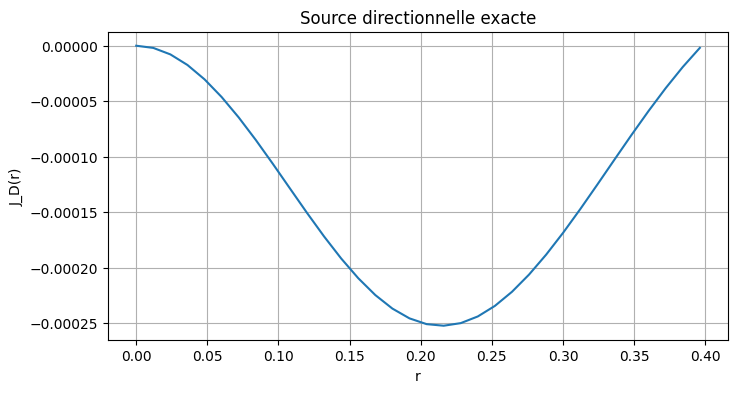

In [9]:

J_D_grid = (
    np.sqrt(2/3)
    * (
        p_r_grid-p_t_grid
    )
)

J_interpolator = PchipInterpolator(
    r_star_grid,
    J_D_grid,
    extrapolate=False
)

def J_D_numeric(radius):
    if radius < r_star_grid[0]:
        return float(J_D_grid[0])

    if radius > R_star:
        return 0.0

    value = J_interpolator(radius)

    return float(
        0.0
        if not np.isfinite(value)
        else value
    )

plt.figure(figsize=(8,4))
plt.plot(r_star_grid,J_D_grid)
plt.xlabel("r")
plt.ylabel("J_D(r)")
plt.title("Source directionnelle exacte")
plt.grid(True)
plt.show()



# 8. Étape 3 — Équation intérieure du champ

À l’intérieur :

\[
d''
+
\frac2rd'
-
\mu_D^2d
=
-\kappa_DJ_D(r).
\]

La régularité au centre impose :

\[
d'(0)=0.
\]

Comme l’équation est linéaire, nous construisons deux solutions :

### Solution particulière

\[
d_p(0)=0,
\qquad
d_p'(0)=0.
\]

### Solution homogène régulière

\[
d_h(0)=1,
\qquad
d_h'(0)=0.
\]

La solution générale intérieure est :

\[
d_{\rm in}(r)
=
d_p(r)+A\,d_h(r).
\]


In [10]:

def solve_interior_field_basis(
    R_star,
    J_function,
    mu=0.5,
    kappa=0.2,
    n_eval=2000
):
    r0 = max(
        1e-6,
        R_star*1e-6
    )

    J0 = J_function(r0)

    def integrate_basis(
        d_center,
        sourced
    ):
        source_center = (
            -kappa*J0
            if sourced
            else 0.0
        )

        d2_center = (
            mu**2*d_center
            + source_center
        )/3

        d0 = (
            d_center
            + 0.5*d2_center*r0**2
        )

        v0 = d2_center*r0

        def rhs(radius,state):
            d_value,v_value = state

            source = (
                -kappa
                * J_function(radius)
                if sourced
                else 0.0
            )

            dv = (
                mu**2*d_value
                - 2*v_value/radius
                + source
            )

            return [
                v_value,
                dv
            ]

        radii = np.linspace(
            r0,
            R_star,
            n_eval
        )

        solution = solve_ivp(
            rhs,
            (r0,R_star),
            [d0,v0],
            t_eval=radii,
            method="DOP853",
            rtol=1e-11,
            atol=1e-13,
            max_step=max(
                R_star/500,
                1e-4
            )
        )

        if not solution.success:
            raise RuntimeError(
                solution.message
            )

        return solution

    particular = integrate_basis(
        d_center=0.0,
        sourced=True
    )

    homogeneous = integrate_basis(
        d_center=1.0,
        sourced=False
    )

    return particular,homogeneous



# 9. Étape 4 — Solution extérieure exacte

Dans le vide :

\[
d_{\rm out}(r)
=
Q_D
\frac{e^{-\mu_Dr}}r.
\]

À la surface :

\[
\frac{d_{\rm out}'(R_\star)}
{d_{\rm out}(R_\star)}
=
-\left(
\mu_D+\frac1{R_\star}
\right).
\]

Nous définissons :

\[
L_\star
=
-\left(
\mu_D+\frac1{R_\star}
\right).
\]


In [11]:

def exterior_log_derivative(
    R_star,
    mu
):
    return -(
        mu+1/R_star
    )



# 10. Étape 5 — Raccordement analytique

À la surface :

\[
d_p'+A d_h'
=
L_\star
(d_p+A d_h).
\]

Donc :

\[
\boxed{
A
=
\frac{
L_\star d_p-d_p'
}{
d_h'-L_\star d_h
}
}.
\]

Une fois \(A\) connu :

\[
d_\star
=
d_p(R_\star)
+
A d_h(R_\star).
\]

La charge extérieure est alors :

\[
\boxed{
Q_D
=
R_\star
e^{\mu_DR_\star}
d_\star
}.
\]


In [12]:

def match_interior_to_exterior(
    particular,
    homogeneous,
    R_star,
    mu
):
    d_p = float(
        particular.y[0,-1]
    )
    v_p = float(
        particular.y[1,-1]
    )

    d_h = float(
        homogeneous.y[0,-1]
    )
    v_h = float(
        homogeneous.y[1,-1]
    )

    L_star = exterior_log_derivative(
        R_star,
        mu
    )

    denominator = (
        v_h-L_star*d_h
    )

    if abs(denominator) < 1e-14:
        raise RuntimeError(
            "Raccordement singulier : dénominateur nul."
        )

    amplitude = (
        L_star*d_p-v_p
    )/denominator

    d_surface = (
        d_p+amplitude*d_h
    )

    v_surface = (
        v_p+amplitude*v_h
    )

    Q_D = (
        R_star
        * np.exp(mu*R_star)
        * d_surface
    )

    derivative_residual = (
        v_surface
        - L_star*d_surface
    )

    return {
        "A_homogeneous":amplitude,
        "d_surface":d_surface,
        "v_surface":v_surface,
        "L_surface":L_star,
        "Q_D":Q_D,
        "matching_residual":derivative_residual
    }



# 11. Solution directionnelle complète de référence


In [13]:

FIELD_PARAMETERS = {
    "mu":0.5,
    "kappa":0.2
}

particular,homogeneous = solve_interior_field_basis(
    R_star,
    J_D_numeric,
    **FIELD_PARAMETERS
)

matching = match_interior_to_exterior(
    particular,
    homogeneous,
    R_star,
    FIELD_PARAMETERS["mu"]
)

matching


{'A_homogeneous': -2.0514124523600384e-06,
 'd_surface': -1.1528682676600926e-06,
 'v_surface': 3.4761693187271474e-06,
 'L_surface': -3.015235492414515,
 'Q_D': np.float64(-5.591570439888084e-07),
 'matching_residual': -8.470329472543003e-22}

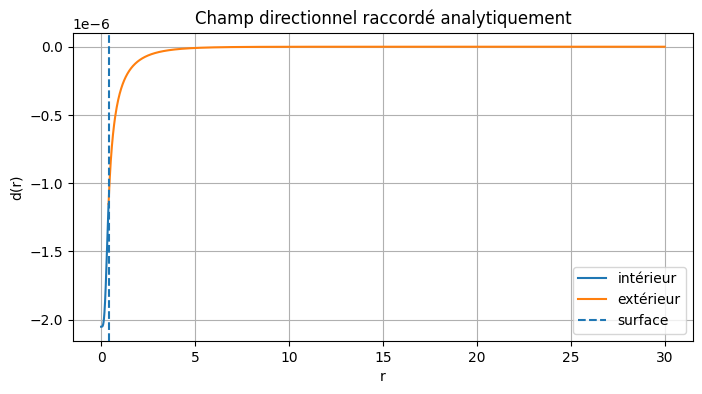

Q_D = -5.591570439888084e-07
Résidu raccordement = -8.470329472543003e-22


In [14]:

A_match = matching[
    "A_homogeneous"
]

r_field_in = particular.t

d_field_in = (
    particular.y[0]
    + A_match*homogeneous.y[0]
)

v_field_in = (
    particular.y[1]
    + A_match*homogeneous.y[1]
)

r_field_out = np.linspace(
    R_star,
    max(5*R_star,30.0),
    1500
)

d_field_out = (
    matching["Q_D"]
    * np.exp(
        -FIELD_PARAMETERS["mu"]
        * r_field_out
    )
    / r_field_out
)

plt.figure(figsize=(8,4))
plt.plot(
    r_field_in,
    d_field_in,
    label="intérieur"
)
plt.plot(
    r_field_out,
    d_field_out,
    label="extérieur"
)
plt.axvline(
    R_star,
    linestyle="--",
    label="surface"
)
plt.xlabel("r")
plt.ylabel("d(r)")
plt.title("Champ directionnel raccordé analytiquement")
plt.grid(True)
plt.legend()
plt.show()

print("Q_D =",matching["Q_D"])
print(
    "Résidu raccordement =",
    matching["matching_residual"]
)



# 12. Vérification indépendante de \(Q_D\)

Dans la solution extérieure :

\[
Q_D(r)
=
r e^{\mu_Dr}d_{\rm out}(r).
\]

Cette quantité doit être constante.


In [15]:

Q_profile = (
    r_field_out
    * np.exp(
        FIELD_PARAMETERS["mu"]
        * r_field_out
    )
    * d_field_out
)

Q_profile_scatter = float(
    np.std(Q_profile)
)

print(
    "Dispersion numérique de Q_D :",
    Q_profile_scatter
)


Dispersion numérique de Q_D : 1.2449991732280351e-22



# 13. Limite isotrope

Lorsque :

\[
\lambda_a=0,
\]

alors :

\[
p_t=p_r,
\qquad
J_D=0.
\]

Avec absence d’excitation libre imposée, la solution physique est :

\[
d(r)=0,
\qquad
Q_D=0.
\]


In [16]:

def solve_star_and_charge(
    lambda_a,
    p_center=0.02,
    K_poly=0.12,
    Gamma_poly=2.0,
    mu=0.5,
    kappa=0.2
):
    star,R_value,M_value = solve_anisotropic_star(
        p_center=p_center,
        K_poly=K_poly,
        Gamma_poly=Gamma_poly,
        lambda_a=lambda_a
    )

    rr = star.t
    mm = star.y[0]
    pr = np.maximum(
        star.y[2],
        0.0
    )

    density = np.array([
        rho_from_pressure(
            p,
            K_poly,
            Gamma_poly
        )
        for p in pr
    ])

    Delta_values = np.array([
        anisotropy_value(
            radius,
            mass,
            pressure,
            rho_value,
            lambda_a
        )
        for radius,mass,pressure,rho_value
        in zip(
            rr,
            mm,
            pr,
            density
        )
    ])

    pt = pr+Delta_values

    J_values = (
        np.sqrt(2/3)
        * (
            pr-pt
        )
    )

    if np.max(
        np.abs(J_values)
    ) < 1e-14:
        return {
            "lambda_a":lambda_a,
            "R_star":R_value,
            "M_star":M_value,
            "Q_D":0.0,
            "matching_residual":0.0,
            "status":"isotropic-zero-source"
        }

    J_interp = PchipInterpolator(
        rr,
        J_values,
        extrapolate=False
    )

    def J_local(radius):
        if radius < rr[0]:
            return float(
                J_values[0]
            )

        if radius > R_value:
            return 0.0

        value = J_interp(radius)

        return float(
            value
            if np.isfinite(value)
            else 0.0
        )

    psol,hsol = solve_interior_field_basis(
        R_value,
        J_local,
        mu=mu,
        kappa=kappa
    )

    matched = match_interior_to_exterior(
        psol,
        hsol,
        R_value,
        mu
    )

    return {
        "lambda_a":lambda_a,
        "R_star":R_value,
        "M_star":M_value,
        "Q_D":matched["Q_D"],
        "matching_residual":matched[
            "matching_residual"
        ],
        "status":"ok"
    }


isotropic_result = solve_star_and_charge(
    0.0
)

isotropic_result


{'lambda_a': 0.0,
 'R_star': 0.3919481337982934,
 'M_star': 0.03113678824087707,
 'Q_D': 0.0,
 'matching_residual': 0.0,
 'status': 'isotropic-zero-source'}


# 14. Scan robuste de l’anisotropie


In [17]:

scan_rows = []

for lambda_value in [
    -0.03,
    -0.02,
    -0.01,
    0.0,
    0.01,
    0.02,
    0.03
]:
    try:
        result = solve_star_and_charge(
            lambda_value
        )
    except Exception as exc:
        result = {
            "lambda_a":lambda_value,
            "R_star":np.nan,
            "M_star":np.nan,
            "Q_D":np.nan,
            "matching_residual":np.nan,
            "status":f"error: {exc}"
        }

    scan_rows.append(result)

anisotropy_scan = pd.DataFrame(
    scan_rows
)

anisotropy_scan["Q_over_M"] = (
    anisotropy_scan["Q_D"]
    / anisotropy_scan["M_star"]
)

anisotropy_scan


,lambda_a,R_star,M_star,Q_D,matching_residual,status,Q_over_M
0,-0.03,0.383804,0.029070,6.857660e-07,0.000000e+00,ok,0.000024
1,-0.02,0.386479,0.029736,4.775523e-07,-8.470329e-22,ok,0.000016
2,-0.01,0.389193,0.030424,2.480098e-07,4.235165e-22,ok,0.000008
3,0.00,0.391948,0.031137,0.000000e+00,0.000000e+00,isotropic-zero-source,0.000000
4,0.01,0.394742,0.031874,-2.674554e-07,2.117582e-22,ok,-0.000008
5,0.02,0.397577,0.032637,-5.591570e-07,-8.470329e-22,ok,-0.000017
6,0.03,0.400451,0.033427,-8.729003e-07,2.541099e-21,ok,-0.000026


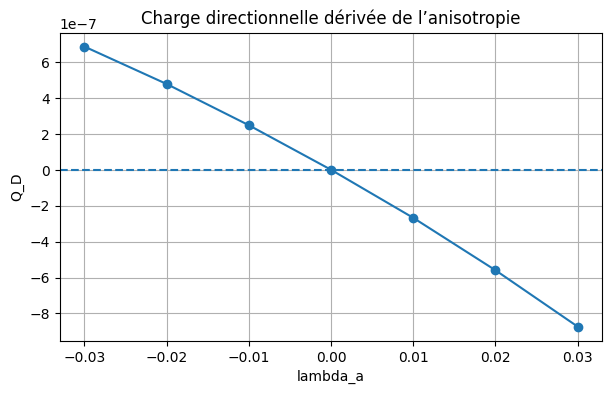

In [18]:

finite_scan = anisotropy_scan[
    np.isfinite(
        anisotropy_scan["lambda_a"]
    )
    & np.isfinite(
        anisotropy_scan["Q_D"]
    )
].copy()

plt.figure(figsize=(7,4))

if len(finite_scan) > 0:
    plt.plot(
        finite_scan["lambda_a"],
        finite_scan["Q_D"],
        marker="o"
    )

plt.axhline(0,linestyle="--")
plt.xlabel("lambda_a")
plt.ylabel("Q_D")
plt.title("Charge directionnelle dérivée de l’anisotropie")
plt.grid(True)
plt.show()



# 15. Ajustement linéaire protégé

Pour une faible anisotropie :

\[
Q_D
\approx
q_1\lambda_a+q_0.
\]


In [19]:

if len(finite_scan) >= 2:
    x_fit = finite_scan[
        "lambda_a"
    ].to_numpy(dtype=float)

    y_fit = finite_scan[
        "Q_D"
    ].to_numpy(dtype=float)

    q_slope,q_intercept = np.polyfit(
        x_fit,
        y_fit,
        deg=1
    )

    Q_prediction = (
        q_slope*x_fit
        + q_intercept
    )

    Q_rmse = float(
        np.sqrt(
            np.mean(
                (
                    Q_prediction-y_fit
                )**2
            )
        )
    )

    fit_status = "PASS"

else:
    q_slope = np.nan
    q_intercept = np.nan
    Q_rmse = np.nan
    fit_status = "INSUFFICIENT-DATA"

print("Points finis :",len(finite_scan))
print("Pente :",q_slope)
print("Intercept :",q_intercept)
print("RMSE :",Q_rmse)
print("Statut :",fit_status)


Points finis : 7
Pente : -2.5946009772004016e-05
Intercept : -4.116923264155849e-08
RMSE : 3.619872446536724e-08
Statut : PASS



# 16. Contrôles physiques


In [20]:

compactness = (
    2*M_star/R_star
)

rho_positive = bool(
    np.all(
        rho_grid >= -1e-12
    )
)

pr_positive = bool(
    np.all(
        p_r_grid >= -1e-12
    )
)

pt_positive = bool(
    np.all(
        p_t_grid >= -1e-10
    )
)

surface_pressure = float(
    p_r_grid[-1]
)

physical_checks = pd.DataFrame([
    {
        "test":"rho >= 0",
        "value":rho_positive
    },
    {
        "test":"p_r >= 0",
        "value":pr_positive
    },
    {
        "test":"p_t >= 0",
        "value":pt_positive
    },
    {
        "test":"2M/R < 1",
        "value":compactness < 1
    },
    {
        "test":"surface pressure near zero",
        "value":abs(surface_pressure) < 1e-4
    }
])

physical_checks


,test,value
0,rho >= 0,True
1,p_r >= 0,True
2,p_t >= 0,True
3,2M/R < 1,True
4,surface pressure near zero,True



# 17. Pont PPN provisoire

En longue portée :

\[
\gamma_{\rm GVH}-1
\approx
(\alpha_s-\alpha_t)
\frac{Q_D}{GM}.
\]

Cette version dérive \(Q_D\) depuis la source anisotrope.

Les coefficients de rétroaction métrique restent à dériver.


In [21]:

gamma_bound = 6.7e-5

Q_reference = matching["Q_D"]

if (
    Q_reference != 0
    and np.isfinite(Q_reference)
):
    slip_bound = (
        gamma_bound
        * abs(
            M_star/Q_reference
        )
    )
else:
    slip_bound = np.inf

ppn_bridge = pd.DataFrame([
    {
        "quantity":"Q_D",
        "value":Q_reference
    },
    {
        "quantity":"Q_D/M",
        "value":Q_reference/M_star
    },
    {
        "quantity":"bound on |alpha_s-alpha_t|",
        "value":slip_bound
    }
])

ppn_bridge


,quantity,value
0,Q_D,-5.591570e-07
1,Q_D/M,-1.713271e-05
2,bound on |alpha_s-alpha_t|,3.910649e+00



# 18. Statut des résultats


In [22]:

result_status = pd.DataFrame([
    {
        "result":"exact spatial projector",
        "status":"DERIVED"
    },
    {
        "result":"J_D=sqrt(2/3)(p_r-p_t)",
        "status":"DERIVED"
    },
    {
        "result":"anisotropic TOV star",
        "status":"NUMERICALLY SOLVED"
    },
    {
        "result":"interior field",
        "status":"SOLVED SEPARATELY"
    },
    {
        "result":"exterior Yukawa field",
        "status":"ANALYTIC"
    },
    {
        "result":"surface matching",
        "status":"ANALYTIC"
    },
    {
        "result":"Q_D",
        "status":"DERIVED FROM MATCHING"
    },
    {
        "result":"metric backreaction",
        "status":"NOT YET DERIVED"
    }
])

result_status


,result,status
0,exact spatial projector,DERIVED
1,J_D=sqrt(2/3)(p_r-p_t),DERIVED
2,anisotropic TOV star,NUMERICALLY SOLVED
3,interior field,SOLVED SEPARATELY
4,exterior Yukawa field,ANALYTIC
5,surface matching,ANALYTIC
6,Q_D,DERIVED FROM MATCHING
7,metric backreaction,NOT YET DERIVED



# 19. Validation automatique


In [23]:

projector_ok = (
    normalization == -1
    and orthogonality == sp.zeros(4,1)
    and idempotence == sp.zeros(4)
    and trace_h == 3
)

source_projector_ok = (
    Pi_trace == 0
    and Pi_spatial == sp.zeros(4,1)
)

isotropic_symbolic_ok = (
    Pi_isotropic == sp.zeros(4)
)

source_formula_ok = (
    sp.simplify(
        J_D_symbolic
        - sp.sqrt(
            sp.Rational(2,3)
        )*Delta
    ) == 0
)

star_ok = (
    np.isfinite(R_star)
    and np.isfinite(M_star)
    and R_star > 0
    and M_star > 0
)

matching_ok = (
    abs(
        matching["matching_residual"]
    ) < 1e-10
)

charge_ok = (
    np.isfinite(
        matching["Q_D"]
    )
)

charge_constancy_ok = (
    Q_profile_scatter < 1e-10
)

isotropic_numeric_ok = (
    isotropic_result["Q_D"] == 0.0
)

scan_ok = (
    len(finite_scan) >= 2
)

fit_ok = (
    fit_status == "PASS"
)

physical_ok = bool(
    physical_checks["value"].all()
)

validation_df = pd.DataFrame([
    {"test":"projector identities","status":"PASS" if projector_ok else "FAIL"},
    {"test":"source projector","status":"PASS" if source_projector_ok else "FAIL"},
    {"test":"symbolic isotropic limit","status":"PASS" if isotropic_symbolic_ok else "FAIL"},
    {"test":"J_D formula","status":"PASS" if source_formula_ok else "FAIL"},
    {"test":"stellar solution","status":"PASS" if star_ok else "FAIL"},
    {"test":"analytic matching","status":"PASS" if matching_ok else "FAIL"},
    {"test":"finite Q_D","status":"PASS" if charge_ok else "FAIL"},
    {"test":"constant exterior charge","status":"PASS" if charge_constancy_ok else "FAIL"},
    {"test":"numeric isotropic limit","status":"PASS" if isotropic_numeric_ok else "FAIL"},
    {"test":"finite anisotropy scan","status":"PASS" if scan_ok else "FAIL"},
    {"test":"linear fit","status":"PASS" if fit_ok else "FAIL"},
    {"test":"physical star checks","status":"PASS" if physical_ok else "CHECK"}
])

validation_df


,test,status
0,projector identities,PASS
1,source projector,PASS
2,symbolic isotropic limit,PASS
3,J_D formula,PASS
4,stellar solution,PASS
5,analytic matching,PASS
6,finite Q_D,PASS
7,constant exterior charge,PASS
8,numeric isotropic limit,PASS
9,finite anisotropy scan,PASS


In [24]:

overall_status = (
    "PASS-SEQUENTIAL-0.2.24"
    if (
        validation_df["status"]
        == "PASS"
    ).all()
    else "CHECK"
)

print("STATUT DU NOTEBOOK :",overall_status)


STATUT DU NOTEBOOK : PASS-SEQUENTIAL-0.2.24



# 20. Export


In [25]:

import json

validation_df.to_csv(
    "GVH_Diagonal_Cubic_0.2.24_Validation.csv",
    index=False
)

anisotropy_scan.to_csv(
    "GVH_Diagonal_Cubic_0.2.24_Anisotropy_Charge_Scan.csv",
    index=False
)

ppn_bridge.to_csv(
    "GVH_Diagonal_Cubic_0.2.24_PPN_Bridge.csv",
    index=False
)

result_status.to_csv(
    "GVH_Diagonal_Cubic_0.2.24_Result_Status.csv",
    index=False
)

stellar_profiles = pd.DataFrame({
    "r":r_star_grid,
    "m":m_star_grid,
    "Phi":Phi_star_grid,
    "rho":rho_grid,
    "p_r":p_r_grid,
    "p_t":p_t_grid,
    "Delta":Delta_grid,
    "J_D":J_D_grid
})

stellar_profiles.to_csv(
    "GVH_Diagonal_Cubic_0.2.24_Stellar_Profiles.csv",
    index=False
)

field_profiles = pd.DataFrame({
    "r":r_field_in,
    "d":d_field_in,
    "d_prime":v_field_in
})

field_profiles.to_csv(
    "GVH_Diagonal_Cubic_0.2.24_Interior_Field.csv",
    index=False
)

fit_export = pd.DataFrame([{
    "n_points":len(finite_scan),
    "q_slope":q_slope,
    "q_intercept":q_intercept,
    "Q_rmse":Q_rmse,
    "fit_status":fit_status
}])

fit_export.to_csv(
    "GVH_Diagonal_Cubic_0.2.24_Linear_Fit.csv",
    index=False
)

metadata = {
    "notebook_status":overall_status,
    "architecture":"sequential star -> source -> interior field -> analytic exterior matching",
    "source_projector":"exact spatial trace-free projector",
    "source_formula":"J_D=sqrt(2/3)(p_r-p_t)",
    "R_star":float(R_star),
    "M_star":float(M_star),
    "Q_D":float(matching["Q_D"]),
    "matching_residual":float(matching["matching_residual"]),
    "finite_scan_points":int(len(finite_scan)),
    "linear_fit_status":fit_status,
    "metric_backreaction":"not yet derived"
}

with open(
    "GVH_Diagonal_Cubic_0.2.24_Metadata.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        metadata,
        f,
        indent=2,
        ensure_ascii=False
    )

print("Exports terminés.")


Exports terminés.



# 21. Conclusion

Cette reconstruction sépare maintenant rigoureusement :

\[
\boxed{
\text{structure stellaire}
}
\]

de :

\[
\boxed{
\text{propagation du champ directionnel}
}.
\]

La source est calculée après la résolution TOV :

\[
\boxed{
J_D(r)
=
\sqrt{\frac23}
[p_r(r)-p_t(r)]
}.
\]

L’équation intérieure est résolue par superposition :

\[
d_{\rm in}
=
d_p+A d_h.
\]

Le raccordement à :

\[
d_{\rm out}
=
Q_D\frac{e^{-\mu_Dr}}r
\]

donne analytiquement :

\[
\boxed{
A
=
\frac{
L_\star d_p-d_p'
}{
d_h'-L_\star d_h
}
}
\]

et :

\[
\boxed{
Q_D
=
R_\star e^{\mu_DR_\star}d_{\rm in}(R_\star)
}.
\]

Cette architecture supprime la cause du tableau vide transmis à `np.polyfit`.

La prochaine étape est :

\[
\boxed{
\texttt{GVH\_Diagonal\_Cubic\_0.2.25\_Coupled\_Modified\_TOV\_Metric\_Backreaction.ipynb}
}
\]
